In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df=pd.read_csv(r"C:\Users\ASUS\Desktop\Projects\YouTube-Video-Popularity-Prediction\data\processed\youtube_data_cleaned.csv")

In [37]:
df.isnull().sum() # No Null Value.

video_id                0
title                   0
published_at            0
category_id             0
duration                0
view_count              0
like_count              0
comment_count           0
channel_subscribers     0
channel_total_views     0
channel_total_videos    0
dtype: int64

In [38]:
df["duration"]  # PT M S TEMİZLENECEK

0      PT11M39S
1       PT8M14S
2      PT13M13S
3      PT17M18S
4      PT38M38S
         ...   
979       PT36S
980     PT4M30S
981       PT38S
982     PT4M30S
983     PT9M32S
Name: duration, Length: 984, dtype: str

In [39]:
import re

def parse_duration(d):
    match = re.match(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', str(d))
    h = int(match.group(1) or 0)
    m = int(match.group(2) or 0)
    s = int(match.group(3) or 0)
    return h*3600 + m*60 + s

df['duration_seconds'] = df['duration'].apply(parse_duration)

In [40]:
df['duration_seconds']

0       699
1       494
2       793
3      1038
4      2318
       ... 
979      36
980     270
981      38
982     270
983     572
Name: duration_seconds, Length: 984, dtype: int64

In [41]:
df.dtypes

video_id                  str
title                     str
published_at              str
category_id             int64
duration                  str
view_count              int64
like_count              int64
comment_count           int64
channel_subscribers     int64
channel_total_views     int64
channel_total_videos    int64
duration_seconds        int64
dtype: object

In [42]:
df['published_at'] = pd.to_datetime(df['published_at'], utc=True)

In [49]:
df['published_at'].iloc[0]
df['published_at'] = df['published_at'].dt.floor('min')
df['published_at']


0     2025-12-22 12:01:00+00:00
1     2026-01-08 14:03:00+00:00
2     2026-01-06 13:00:00+00:00
3     2026-05-02 10:54:00+00:00
4     2026-01-02 11:00:00+00:00
                 ...           
979   2025-02-14 13:40:00+00:00
980   2026-03-26 06:45:00+00:00
981   2025-04-28 16:09:00+00:00
982   2026-01-25 11:09:00+00:00
983   2025-10-26 17:30:00+00:00
Name: published_at, Length: 984, dtype: datetime64[us, UTC]

In [50]:
from datetime import datetime, timezone

now = datetime.now(timezone.utc)
df['days_since_published'] = (now - df['published_at']).dt.days
df['days_since_published'] = df['days_since_published'].replace(0, 1)  

df['daily_avg_views'] = df['view_count'] / df['days_since_published']

In [51]:
df['daily_avg_views']

0      2910.060150
1        38.886957
2      3378.381356
3         0.000000
4       206.065574
          ...     
979     464.015801
980       1.538462
981    3011.240541
982       6.010101
983      67.058201
Name: daily_avg_views, Length: 984, dtype: float64

In [53]:
threshold = df['daily_avg_views'].median()
threshold 

np.float64(303.08933190334994)

In [58]:
df.head()

,video_id,title,published_at,category_id,duration,view_count,like_count,comment_count,channel_subscribers,channel_total_views,channel_total_videos,duration_seconds,days_since_published,daily_avg_views,is_popular
0,zt0JA5rxdfM,"AI Trends 2026: Quantum, Agentic AI & Smarter ...",2025-12-22 12:01:00+00:00,27,PT11M39S,387038,9420,1085,1670000,116404163,1630,699,133,2910.060150,1
1,QkRHuoHygiE,Generative AI Trends in 2026 | Top 10 Generati...,2026-01-08 14:03:00+00:00,27,PT8M14S,4472,132,4,4440000,465475950,11848,494,115,38.886957,0
2,B23W1gRT9eY,Top 6 AI Trends That Will Define 2026 (backed ...,2026-01-06 13:00:00+00:00,27,PT13M13S,398649,8651,830,1710000,95539701,304,793,118,3378.381356,1
3,VunjURBzNow,"Top 20 AI & ML Trends in 2026 | Agents, Genera...",2026-05-02 10:54:00+00:00,24,PT17M18S,0,0,0,318,78,16,1038,2,0.000000,0
4,ARXS-uk19h8,AI year in review: Trends shaping 2026,2026-01-02 11:00:00+00:00,27,PT38M38S,25140,441,43,1670000,116404163,1630,2318,122,206.065574,0


In [55]:
df['is_popular'] = (df['daily_avg_views'] >= threshold).astype(int)
df['is_popular']


0      1
1      0
2      1
3      0
4      0
      ..
979    1
980    0
981    1
982    0
983    0
Name: is_popular, Length: 984, dtype: int64

In [59]:
df['publish_hour'] = df['published_at'].dt.hour
df['publish_dayofweek'] = df['published_at'].dt.dayofweek
df['is_weekend'] = df['publish_dayofweek'].isin([5, 6]).astype(int)
df['is_prime_time'] = df['publish_hour'].between(17, 22).astype(int) # Select those hours as prime time .

In [60]:
df['title_word_count'] = df['title'].str.split().str.len()
df['title_char_count'] = df['title'].str.len()
df['title_upper_ratio'] = df['title'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1))
df['title_has_question'] = df['title'].str.contains(r'\?', na=False).astype(int)
df['title_has_exclamation'] = df['title'].str.contains(r'!', na=False).astype(int)

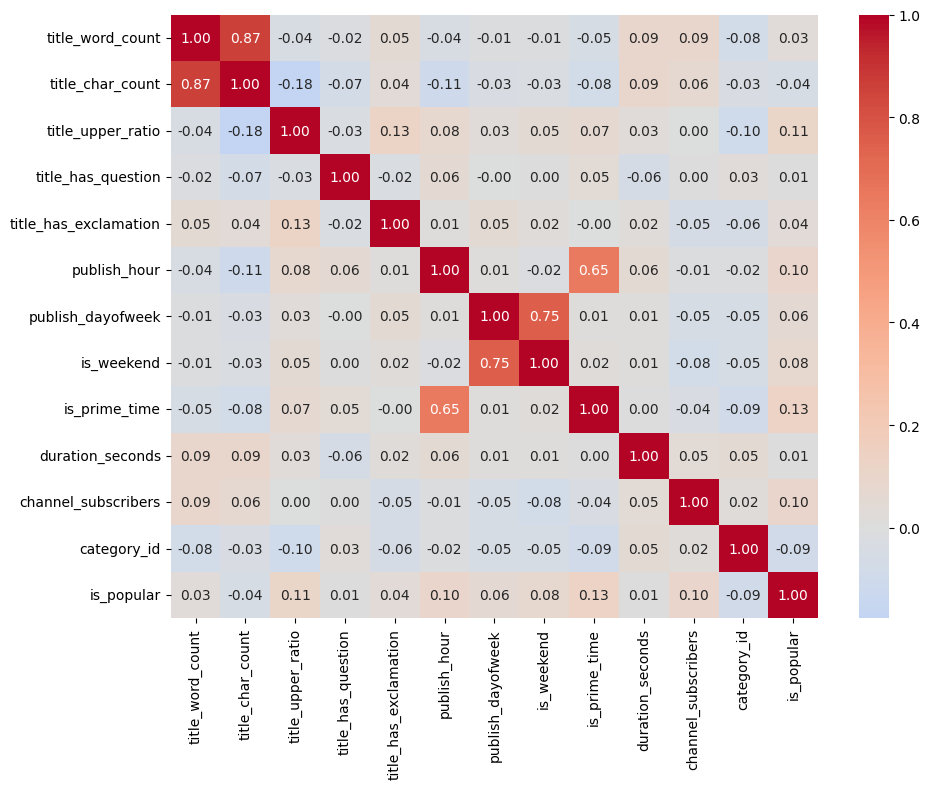

In [75]:
feature_cols = [
    'title_word_count', 'title_char_count', 'title_upper_ratio',
    'title_has_question', 'title_has_exclamation',
    'publish_hour', 'publish_dayofweek', 'is_weekend', 'is_prime_time',
    'duration_seconds', 'channel_subscribers', 'category_id', 'is_popular',
]

corr = df[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()

import os
output_dir = r"C:\Users\ASUS\Desktop\Projects\YouTube-Video-Popularity-Prediction\results\plots"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "feature_correlation_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

In [76]:
df

,video_id,title,published_at,category_id,duration,view_count,like_count,comment_count,channel_subscribers,channel_total_views,...,is_popular,publish_hour,publish_dayofweek,is_weekend,is_prime_time,title_word_count,title_char_count,title_upper_ratio,title_has_question,title_has_exclamation
0,zt0JA5rxdfM,"AI Trends 2026: Quantum, Agentic AI & Smarter ...",2025-12-22 12:01:00+00:00,27,PT11M39S,387038,9420,1085,1670000,116404163,...,1,12,0,0,0,9,56,0.160714,0,0
1,QkRHuoHygiE,Generative AI Trends in 2026 | Top 10 Generati...,2026-01-08 14:03:00+00:00,27,PT8M14S,4472,132,4,4440000,465475950,...,0,14,3,0,0,15,81,0.135802,0,0
2,B23W1gRT9eY,Top 6 AI Trends That Will Define 2026 (backed ...,2026-01-06 13:00:00+00:00,27,PT13M13S,398649,8651,830,1710000,95539701,...,1,13,1,0,0,11,54,0.129630,0,0
3,VunjURBzNow,"Top 20 AI & ML Trends in 2026 | Agents, Genera...",2026-05-02 10:54:00+00:00,24,PT17M18S,0,0,0,318,78,...,0,10,5,1,0,17,89,0.157303,0,0
4,ARXS-uk19h8,AI year in review: Trends shaping 2026,2026-01-02 11:00:00+00:00,27,PT38M38S,25140,441,43,1670000,116404163,...,0,11,4,0,0,7,38,0.078947,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,GlgTI_Gd9_g,MAHARASHTRA to Get INNOVATION City like GIFT c...,2025-02-14 13:40:00+00:00,27,PT36S,205559,8283,239,66000,53214805,...,1,13,4,0,0,10,60,0.450000,0,0
980,u25zjz6x1ow,HydroStride X 💧⚡ | Smart Eco Public Infrastruc...,2026-03-26 06:45:00+00:00,27,PT4M30S,60,13,0,2550,169550,...,0,6,3,0,0,14,86,0.116279,0,0
981,WoH2BEKb4Wo,Top 10 most planned cities in India #top10 #pl...,2025-04-28 16:09:00+00:00,27,PT38S,1114159,20962,642,89900,77534922,...,1,16,0,0,0,13,94,0.021277,0,0
982,bKfetn_IP0Y,Smart Cities Week 1 | NPTEL ANSWERS 2026 #npte...,2026-01-25 11:09:00+00:00,27,PT4M30S,595,8,0,33500,5854741,...,0,11,6,1,0,12,79,0.189873,0,0


In [77]:
output_path = r"C:\Users\ASUS\Desktop\Projects\YouTube-Video-Popularity-Prediction\data\processed\features_data.csv"
df.to_csv(output_path, index=False)
output_path

'C:\\Users\\ASUS\\Desktop\\Projects\\YouTube-Video-Popularity-Prediction\\data\\processed\\features_data.csv'

In [82]:
filtered_cols = [
    "channel_subscribers",
    "category_id",
    "title_word_count",
    "title_char_count",
    "title_upper_ratio",
    "title_has_question",
    "title_has_exclamation",
    "publish_dayofweek",
    "publish_hour",
    "is_weekend",
    "is_prime_time","is_popular"
]
filtered_output_path = r"C:\Users\ASUS\Desktop\Projects\YouTube-Video-Popularity-Prediction\data\processed\filtered_feature_data.csv"
df[filtered_cols].to_csv(filtered_output_path, index=False)
filtered_output_path

'C:\\Users\\ASUS\\Desktop\\Projects\\YouTube-Video-Popularity-Prediction\\data\\processed\\filtered_feature_data.csv'

In [79]:
new_data=pd.read_csv(r"C:\Users\ASUS\Desktop\Projects\YouTube-Video-Popularity-Prediction\data\processed\filtered_feature_data.csv")

In [81]:
new_data.head()

,channel_subscribers,category_id,title_word_count,title_char_count,title_upper_ratio,title_has_question,title_has_exclamation,publish_dayofweek,publish_hour,is_weekend,is_prime_time
0,1670000,27,9,56,0.160714,0,0,0,12,0,0
1,4440000,27,15,81,0.135802,0,0,3,14,0,0
2,1710000,27,11,54,0.129630,0,0,1,13,0,0
3,318,24,17,89,0.157303,0,0,5,10,1,0
4,1670000,27,7,38,0.078947,0,0,4,11,0,0
